## Install Ultralytics (YOLO26)

In [1]:
!pip install ultralytics -q

import ultralytics
ultralytics.checks()
print(f"\nUltralytics versi: {ultralytics.__version__}")

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)

Ultralytics versi: 8.4.63


## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive berhasil di-mount!")

Mounted at /content/drive
Google Drive berhasil di-mount!


In [3]:
import os

def tampilkan_struktur(path, indent=0, max_depth=4, max_files=10):
    """Tampilkan struktur folder secara rekursif."""
    if indent > max_depth:
        return

    try:
        items = sorted(os.listdir(path))
    except PermissionError:
        print(' ' * indent + '❌ Akses ditolak')
        return

    folders = [i for i in items if os.path.isdir(os.path.join(path, i))]
    files   = [i for i in items if os.path.isfile(os.path.join(path, i))]

    for folder in folders:
        print(' ' * indent + f'📁 {folder}/')
        tampilkan_struktur(os.path.join(path, folder), indent+4, max_depth, max_files)

    for i, file in enumerate(files):
        if i >= max_files:
            print(' ' * indent + f'   ... (+{len(files)-max_files} file lainnya)')
            break
        size = os.path.getsize(os.path.join(path, file))
        size_str = f'{size/1e6:.1f} MB' if size > 1e6 else f'{size/1e3:.1f} KB'
        print(' ' * indent + f' {file}  ({size_str})')

# Ganti path ini sesuai folder utama proyek kamu di Drive
TARGET = '/content/drive/MyDrive/Indonesian_Plate_Recognition'

print(f'📂 Struktur folder: {TARGET}\n')
tampilkan_struktur(TARGET)

📂 Struktur folder: /content/drive/MyDrive/Indonesian_Plate_Recognition

📁 dataset/
    📁 images/
    📁 labels/
     classes.names  (0.1 KB)
     train.txt  (0.0 KB)
     val.txt  (0.0 KB)
📁 hasil_inferensi/
     hasil_2model_yolo26.jpg  (3.4 MB)
     hasil_deteksi_yolo26_char.jpg  (3.4 MB)
📁 trained_models/
    📁 yolo26s/
 modelv8.pt  (6.2 MB)
 parkiran.jpeg  (1.6 MB)


## Verifikasi Struktur Dataset

In [4]:
import os

DATASET_PATH = '/content/drive/MyDrive/Indonesian_Plate_Recognition/dataset'

print("Struktur Dataset:")
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}📂 {os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # tampilkan max 5 file
            print(f'{subindent}📄 {file}')
        if len(files) > 5:
            print(f'{subindent}... dan {len(files)-5} file lainnya')

# Hitung jumlah gambar
print("\nJumlah Data:")
for split in ['train', 'val', 'test']:
    img_path = os.path.join(DATASET_PATH, 'images', split)
    lbl_path = os.path.join(DATASET_PATH, 'labels', split)
    if os.path.exists(img_path):
        imgs = len([f for f in os.listdir(img_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
        lbls = len([f for f in os.listdir(lbl_path) if f.endswith('.txt')]) if os.path.exists(lbl_path) else 0
        print(f"  {split:5s}: {imgs:4d} gambar | {lbls:4d} label")
print("Verifikasi selesai!")

Struktur Dataset:
📂 dataset/
  📄 train.txt
  📄 val.txt
  📄 classes.names
  📂 labels/
    📄 .DS_Store
    📄 train.cache
    📄 val.cache
    📂 test/
    📂 val/
    📂 train/
  📂 images/
    📄 .DS_Store
    📂 val/
    📂 test/
    📂 train/

Jumlah Data:
  train: 1530 gambar | 1530 label
  val  :  179 gambar |  179 label
  test :  197 gambar |  197 label
Verifikasi selesai!


## Baca Classes & Buat File YAML

In [5]:
import yaml

classes_file = os.path.join(DATASET_PATH, 'classes.names')

with open(classes_file, 'r') as f:
    classes = [line.strip() for line in f.readlines() if line.strip()]

print(f"Jumlah kelas: {len(classes)}")
print(f"Nama kelas  : {classes}")

yaml_config = {
    'path': DATASET_PATH,
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc': len(classes),
    'names': classes
}

yaml_path = '/content/indonesian_plate.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_config, f, default_flow_style=False, allow_unicode=True)

print(f"\nFile YAML berhasil dibuat di: {yaml_path}")
print("\nIsi file YAML:")
with open(yaml_path, 'r') as f:
    print(f.read())

Jumlah kelas: 36
Nama kelas  : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

File YAML berhasil dibuat di: /content/indonesian_plate.yaml

Isi file YAML:
names:
- '0'
- '1'
- '2'
- '3'
- '4'
- '5'
- '6'
- '7'
- '8'
- '9'
- A
- B
- C
- D
- E
- F
- G
- H
- I
- J
- K
- L
- M
- N
- O
- P
- Q
- R
- S
- T
- U
- V
- W
- X
- Y
- Z
nc: 36
path: /content/drive/MyDrive/Indonesian_Plate_Recognition/dataset
test: images/test
train: images/train
val: images/val



## Training YOLO26s


In [6]:
from ultralytics import YOLO

MODEL_VARIANT = 'yolo26s.pt'
EPOCHS        = 100
IMG_SIZE      = 640
BATCH_SIZE    = 16
PROJECT_NAME  = 'indonesian_plate_yolo26'
RUN_NAME      = 'yolo26s_exp1'
PATIENCE      = 20

model = YOLO(MODEL_VARIANT)
print(f"✅ Model {MODEL_VARIANT} berhasil dimuat!")

print("\nMemulai training")
results = model.train(
    data      = yaml_path,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    project   = PROJECT_NAME,
    name      = RUN_NAME,
    patience  = PATIENCE,
    device    = 0,
    workers   = 2,
    cache     = False,
    verbose   = True,
    # Augmentasi
    hsv_h     = 0.015,
    hsv_v     = 0.4,
    fliplr    = 0.5,
    mosaic    = 1.0,
)

print("\nTraining selesai!")

✅ Model yolo26s.pt berhasil dimuat!

Memulai training
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/indonesian_plate.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26s_exp1, nbs=64, nms=False, opset=None, opti

## Evaluasi Model (Validasi)

In [7]:
best_model_path = '/content/runs/detect/indonesian_plate_yolo26/yolo26s_exp1/weights/best.pt'
print(f"📂 Path model terbaik: {best_model_path}")

best_model = YOLO(best_model_path)


val_results = best_model.val(
    data   = yaml_path,
    imgsz  = IMG_SIZE,
    batch  = BATCH_SIZE,
    device = 0
)

print("\nHasil Evaluasi:")
print(f"  mAP@50    : {val_results.box.map50:.4f}")
print(f"  mAP@50-95 : {val_results.box.map:.4f}")
print(f"  Precision : {val_results.box.mp:.4f}")
print(f"  Recall    : {val_results.box.mr:.4f}")

📂 Path model terbaik: /content/runs/detect/indonesian_plate_yolo26/yolo26s_exp1/weights/best.pt
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,479,112 parameters, 0 gradients, 20.6 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 13.5±4.9 MB/s, size: 24.8 KB)
val: Scanning /content/drive/MyDrive/Indonesian_Plate_Recognition/dataset/labels/val.cache... 179 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 179/179 46.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.0it/s 4.0s
                   all        179       1321      0.946      0.944      0.978      0.722
                     0         48         50      0.969       0.96      0.991      0.773
                     1        132        170       0.99      0.982      0.995      0.694
                     2         68         81      0.987      0.951      0.989      0.751
 

## Visualisasi Hasil Training

Grafik Training:


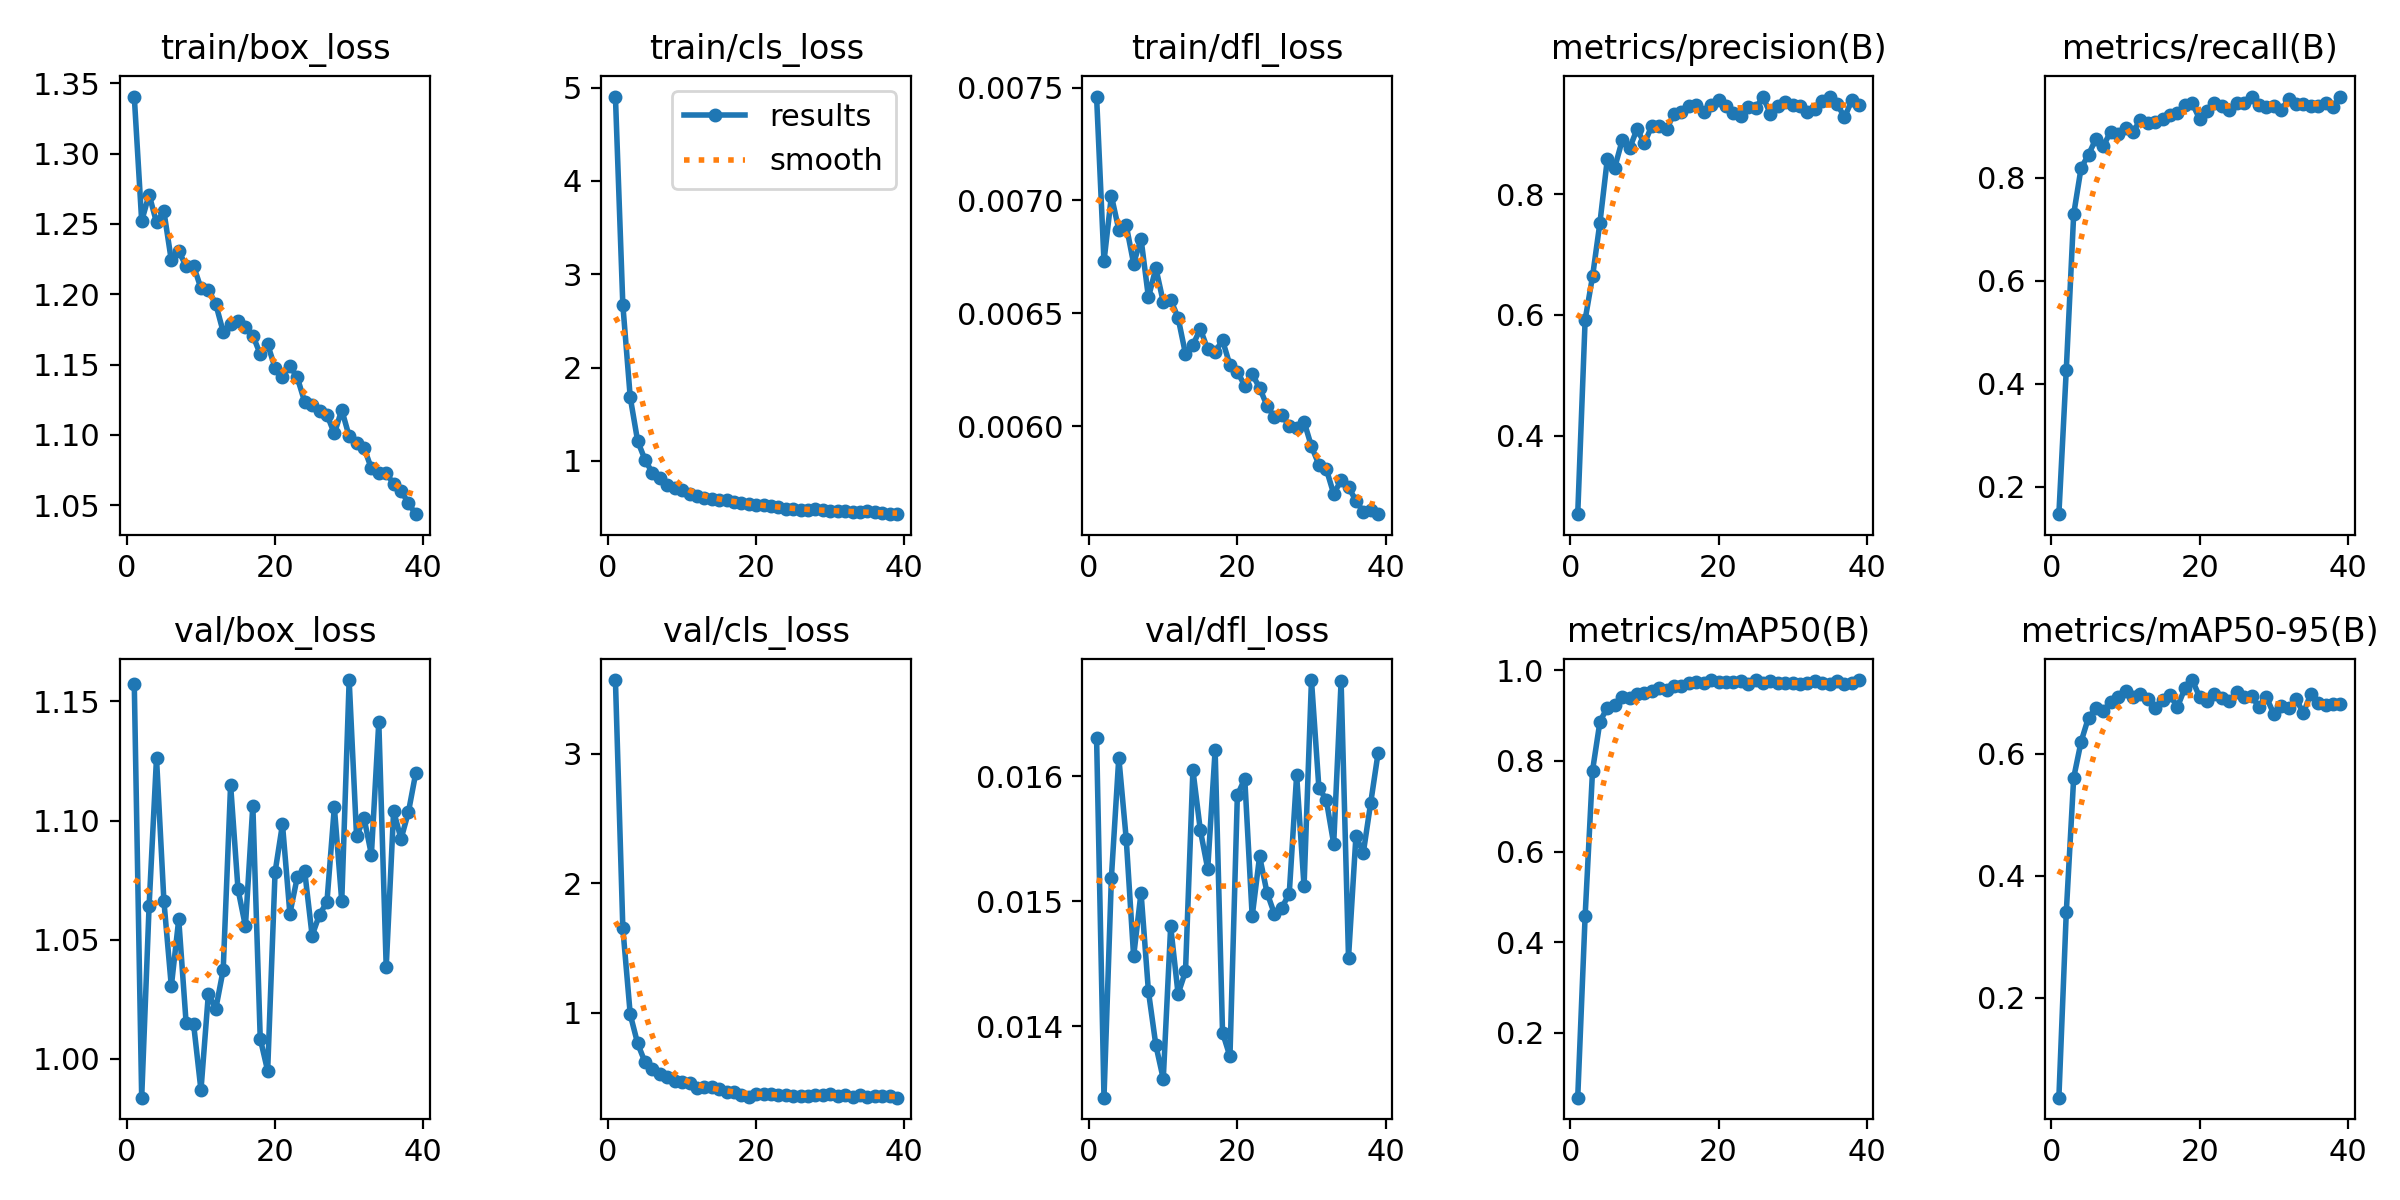


Confusion Matrix:


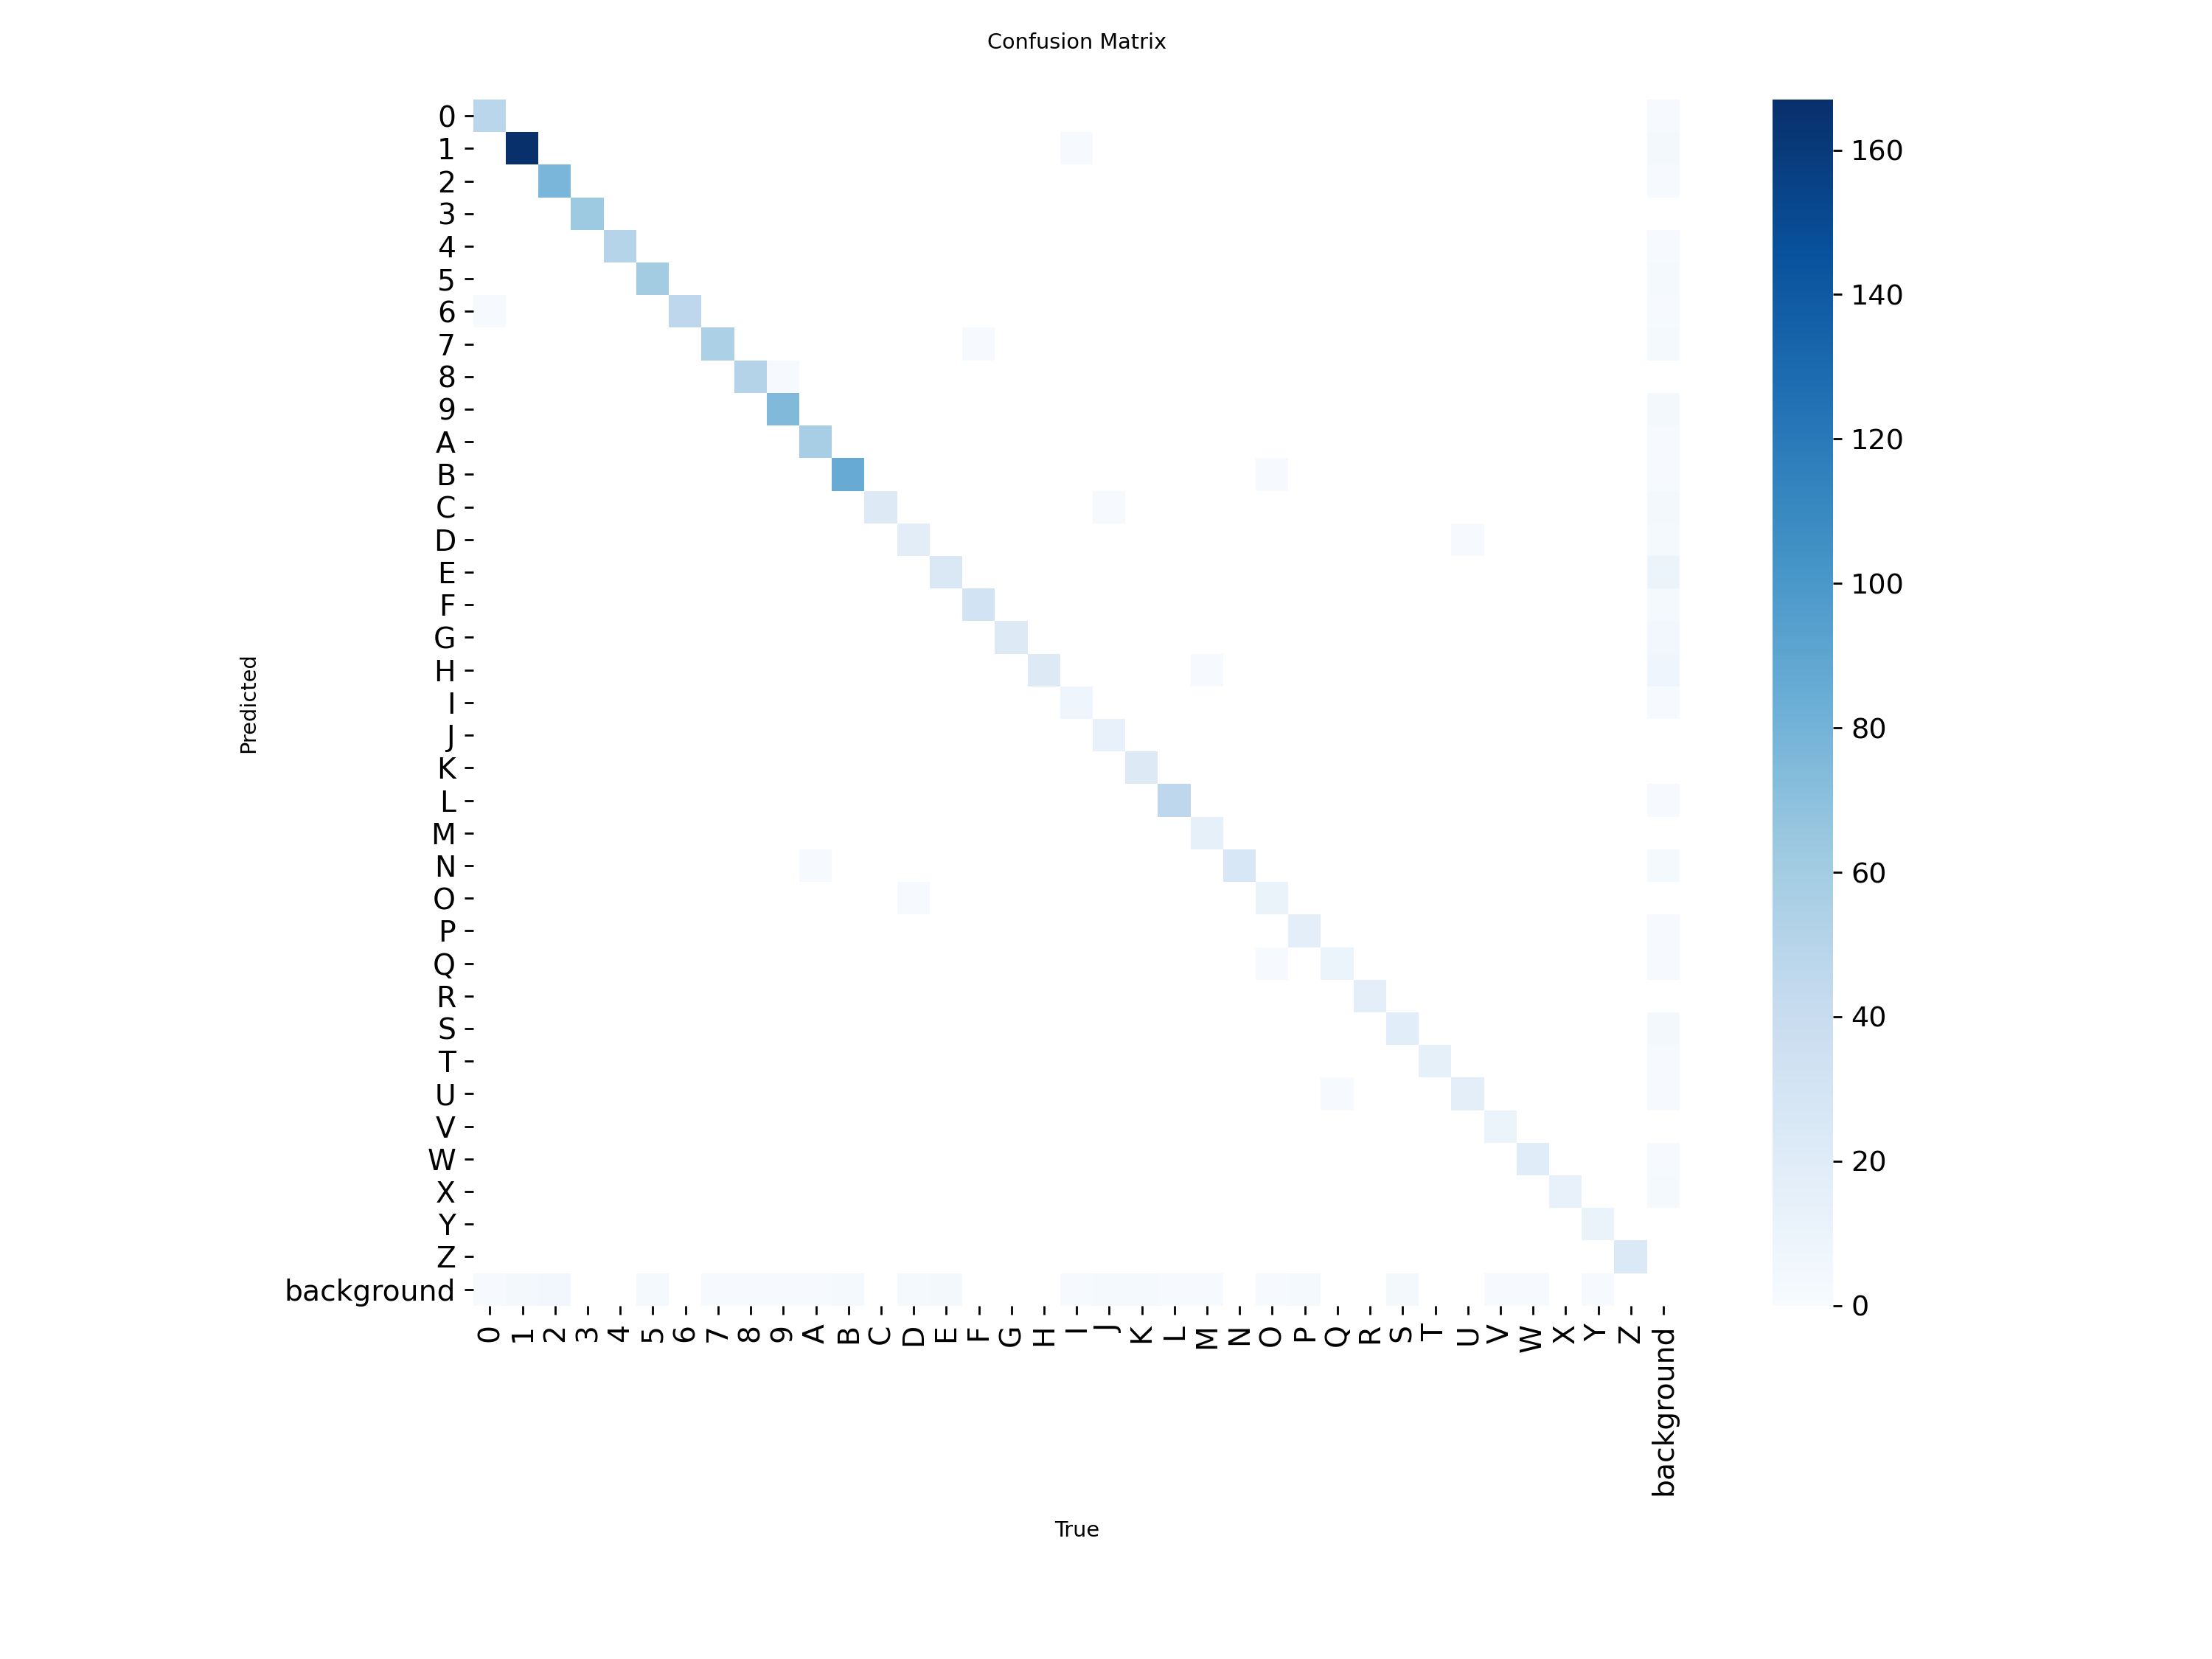


Contoh Prediksi (Val Set):


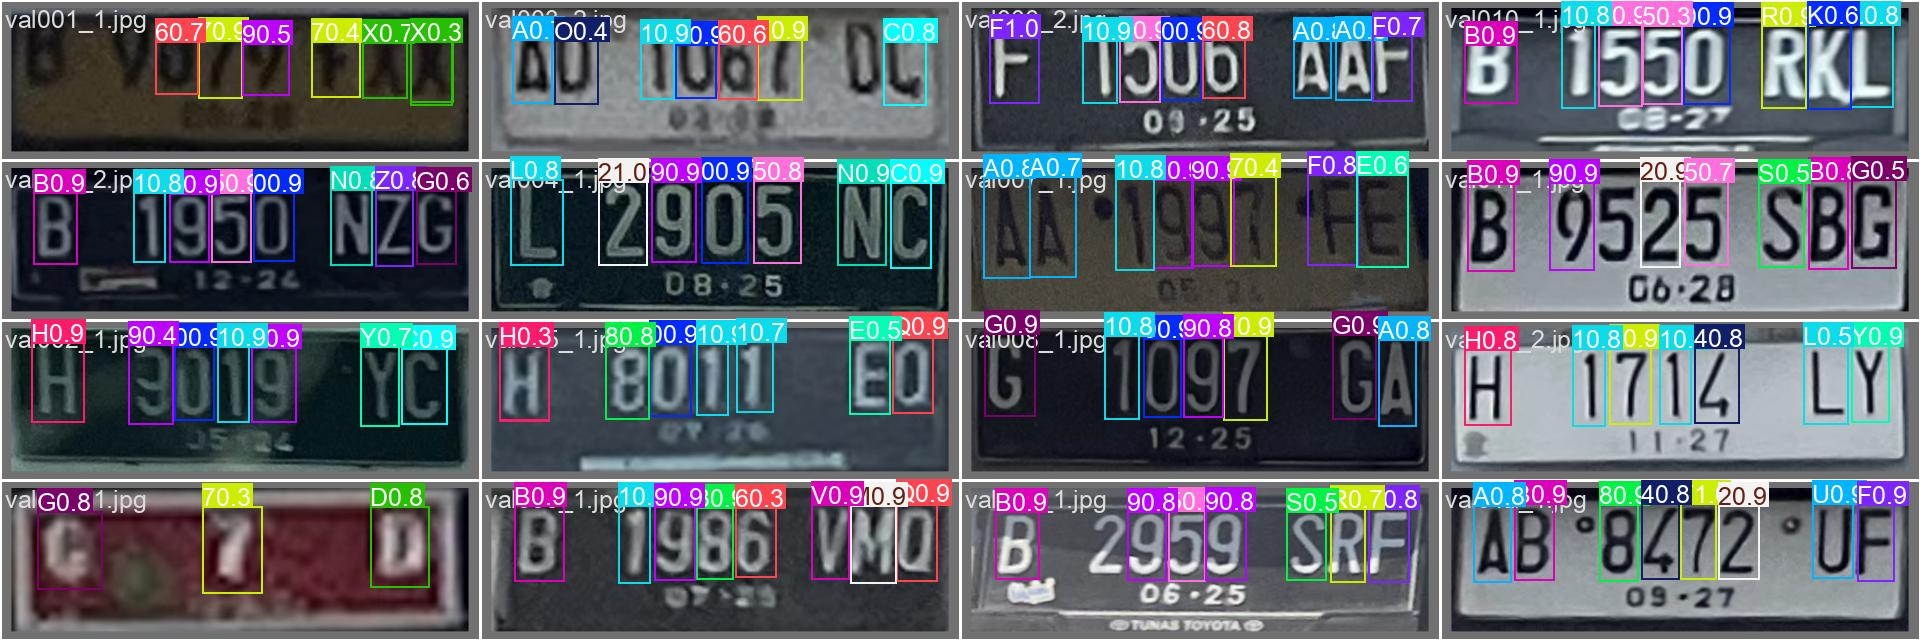

In [8]:
from IPython.display import Image, display
import glob

result_dir = f'/content/runs/detect/{PROJECT_NAME}/{RUN_NAME}/'

print("Grafik Training:")
results_png = os.path.join(result_dir, 'results.png')
if os.path.exists(results_png):
    display(Image(results_png, width=900))

print("\nConfusion Matrix:")
cm_path = os.path.join(result_dir, 'confusion_matrix.png')
if os.path.exists(cm_path):
    display(Image(cm_path, width=600))

print("\nContoh Prediksi (Val Set):")
val_pred = os.path.join(result_dir, 'val_batch0_pred.jpg')
if os.path.exists(val_pred):
    display(Image(val_pred, width=700))

## Inferensi / Test pada Gambar Baru

Menjalankan inferensi pada 5 gambar...

0: 224x640 2 1s, 1 4, 1 7, 1 H, 1 U, 1 Y, 15.7ms
1: 224x640 1 1, 2 9s, 1 B, 1 J, 1 K, 1 V, 15.7ms
2: 224x640 1 1, 1 4, 1 6, 1 9, 1 B, 1 C, 1 N, 1 P, 15.7ms
3: 224x640 1 0, 1 1, 1 4, 1 9, 2 Bs, 1 C, 1 D, 15.7ms
4: 224x640 1 1, 1 5, 2 8s, 1 A, 1 H, 1 N, 15.7ms
Speed: 1.8ms preprocess, 15.7ms inference, 0.3ms postprocess per image at shape (1, 3, 224, 640)
Results saved to /content/runs/detect/indonesian_plate_yolo26/predict_test

 Hasil Prediksi:


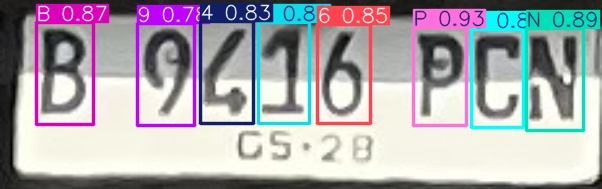

  → image2.jpg


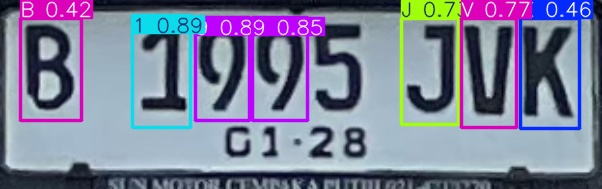

  → image1.jpg


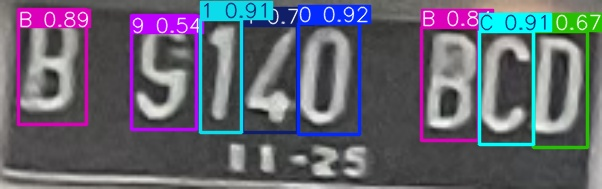

  → image3.jpg


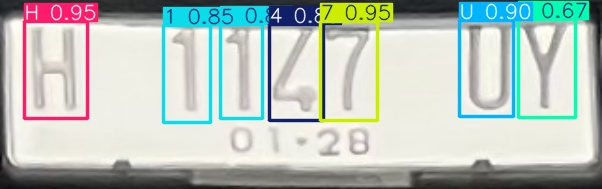

  → image0.jpg


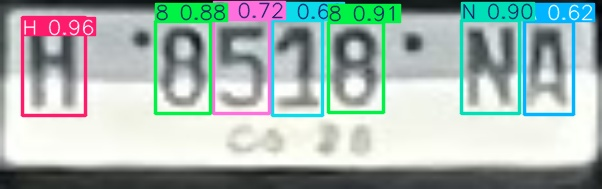

  → image4.jpg


In [9]:
import glob
from IPython.display import Image as IPImage, display

test_images = glob.glob(os.path.join(DATASET_PATH, 'images/test/*.jpg'))[:5]
test_images += glob.glob(os.path.join(DATASET_PATH, 'images/test/*.jpeg'))[:5]
test_images += glob.glob(os.path.join(DATASET_PATH, 'images/test/*.png'))[:5]
test_images = test_images[:5]

if not test_images:
    print("Tidak ada gambar test, menggunakan gambar dari val set...")
    test_images = glob.glob(os.path.join(DATASET_PATH, 'images/val/*.jpg'))[:5]

print(f"Menjalankan inferensi pada {len(test_images)} gambar...")

predictions = best_model.predict(
    source     = test_images,
    imgsz      = IMG_SIZE,
    conf       = 0.25,
    iou        = 0.45,
    save       = True,
    project    = PROJECT_NAME,
    name       = 'predict_test',
    device     = 0
)

print("\n Hasil Prediksi:")
pred_images = glob.glob(f'/content/runs/detect/{PROJECT_NAME}/predict_test/*.jpg')
pred_images += glob.glob(f'/content/runs/detect/{PROJECT_NAME}/predict_test/*.png')
for img_path in pred_images[:5]:
    display(IPImage(img_path, width=500))
    print(f"  → {os.path.basename(img_path)}")

## Simpan Model ke Google Drive

In [10]:
import shutil

# Path Google Drive
SAVE_DIR = '/content/drive/MyDrive/Indonesian_Plate_Recognition/trained_models/yolo26s'
os.makedirs(SAVE_DIR, exist_ok=True)

best_pt = f'/content/runs/detect/{PROJECT_NAME}/{RUN_NAME}/weights/best.pt'
last_pt = f'/content/runs/detect/{PROJECT_NAME}/{RUN_NAME}/weights/last.pt'

if os.path.exists(best_pt):
    shutil.copy(best_pt, os.path.join(SAVE_DIR, 'best.pt'))
    print(f"best.pt disimpan ke Google Drive")

if os.path.exists(last_pt):
    shutil.copy(last_pt, os.path.join(SAVE_DIR, 'last.pt'))
    print(f" last.pt disimpan ke Google Drive")

# Salin grafik training
results_src = f'/content/runs/detect/{PROJECT_NAME}/{RUN_NAME}/results.png'
if os.path.exists(results_src):
    shutil.copy(results_src, os.path.join(SAVE_DIR, 'training_results.png'))
    print(f" Grafik training disimpan ke Google Drive")

# Simpan juga file YAML config
shutil.copy(yaml_path, os.path.join(SAVE_DIR, 'indonesian_plate.yaml'))
print(f"File YAML disimpan ke Google Drive")

print(f"\n🎉 Semua file disimpan ke: {SAVE_DIR}")

best.pt disimpan ke Google Drive
 last.pt disimpan ke Google Drive
 Grafik training disimpan ke Google Drive
File YAML disimpan ke Google Drive

🎉 Semua file disimpan ke: /content/drive/MyDrive/Indonesian_Plate_Recognition/trained_models/yolo26s


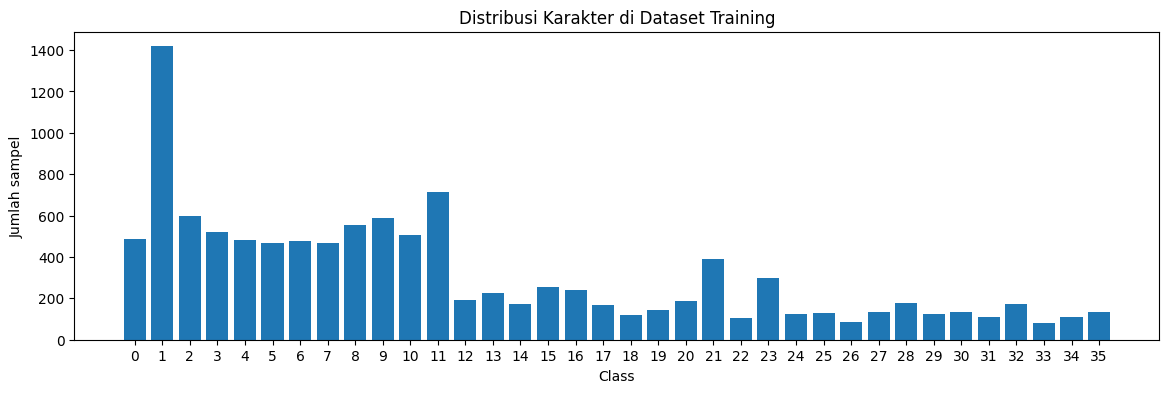

In [12]:
import os
from collections import Counter

label_dir = '/content/drive/MyDrive/Indonesian_Plate_Recognition/dataset/labels/train'
char_count = Counter()

for f in os.listdir(label_dir):
    with open(os.path.join(label_dir, f)) as fp:
        for line in fp:
            cls = int(line.split()[0])
            char_count[cls] += 1

# Tampilkan karakter yang paling sedikit sampelnya
import matplotlib.pyplot as plt
labels = [str(k) for k in sorted(char_count.keys())]
counts = [char_count[k] for k in sorted(char_count.keys())]
plt.figure(figsize=(14,4))
plt.bar(labels, counts)
plt.title('Distribusi Karakter di Dataset Training')
plt.xlabel('Class'); plt.ylabel('Jumlah sampel')
plt.show()

## 📌 LANGKAH 11 (OPSIONAL): Export Model ke Format Lain

In [ ]:
# Export ke ONNX (untuk deployment di berbagai platform)
# Uncomment baris di bawah jika ingin export

# export_model = YOLO(best_model_path)

# # Export ke ONNX
# export_model.export(format='onnx', imgsz=IMG_SIZE)
# print("✅ Model diekspor ke format ONNX")

# # Export ke TensorRT (untuk NVIDIA GPU - inferensi lebih cepat)
# export_model.export(format='engine', imgsz=IMG_SIZE)
# print("✅ Model diekspor ke format TensorRT")

# # Export ke TFLite (untuk mobile/edge devices)
# export_model.export(format='tflite', imgsz=IMG_SIZE)
# print("✅ Model diekspor ke format TFLite")

print("ℹ️ Cell ini opsional. Uncomment format yang diinginkan untuk export model.")